In [25]:
import ipywidgets as widgets
from IPython.display import display

In [1]:
from utils import dataloader

import yaml

import numpy as np
import pandas as pd

from tqdm import tqdm

import nibabel as nib

/home/petron/AIMS/Thesis/TRACE_Algonauts/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


[fetch_atlas_schaefer_2018] Dataset found in /home/petron/nilearn_data/schaefer_2018


In [2]:
with open('configs/dirs.yaml', 'r') as f:
    dir_configs = yaml.safe_load(f)

TRANSCRIPT_DIR = dir_configs['TRANSCRIPT_DIR']
FMRI_DIR = dir_configs['FMRI_DIR']

# Data Loading Test

#### Get Stimuli Info +  Load Transcript

In [6]:
# @title Get Stimuli Info per subject

subject = 1

fmri_stimuli_info = dataloader.list_fmri_sessions(
    dir=FMRI_DIR,
    subject=subject,
    split='train'
)

In [ ]:
fmri_stimuli_info

In [9]:
fmri_stimuli_info[0][13:]

's01e02a'

In [10]:
# @title Load stimuli transcript

transcript_df = dataloader.load_transcript(
    dir = TRANSCRIPT_DIR, 
    stimuli_name=fmri_stimuli_info[0],
    split='train',
    ignore_nans=True
    )

transcript_df.shape

(366, 4)

In [11]:
transcript_df

,text_per_tr,words_per_tr,onsets_per_tr,durations_per_tr
0,You.,['You.'],[0.33],[0.55]
1,What you guys don't,"['What', 'you', 'guys', ""don't""]","[1.89, 2.228, 2.388, 2.612]","[0.316, 0.138, 0.186, 0.214]"
2,"understand is, for us,","['understand', 'is,', 'for', 'us,']","[2.858, 3.22, 3.556, 3.812]","[0.292, 0.282, 0.218, 0.586]"
3,kissing is as important,"['kissing', 'is', 'as', 'important']","[4.564, 5.098, 5.268, 5.428]","[0.502, 0.148, 0.138, 0.33]"
4,as any part of it.,"['as', 'any', 'part', 'of', 'it.']","[5.844, 6.068, 6.292, 6.468, 6.628]","[0.202, 0.186, 0.154, 0.138, 0.522]"
...,...,...,...,...
473,She's,"[""She's""]",[705.37],[0.68]
474,pregnant with my,"['pregnant', 'with', 'my']","[706.13, 706.706, 707.036]","[0.512, 0.276, 0.218]"
475,child.,['child.'],[707.292],[0.588]
476,And she and Susan are going,"['And', 'she', 'and', 'Susan', 'are', 'going']","[708.97, 709.436, 709.628, 709.788, 710.178, 7...","[0.412, 0.17, 0.138, 0.358, 0.196, 0.154]"


#### Load Subject fMRI data per stimuli & subject atlas

In [13]:
# @title Load subject fMRI resposnes data for a specific stimuli

subject = 5

recording_session = '001'
season = '01'
episode = '02'
episode_split = 'b'

fmri_key = f'ses-{recording_session}_task-s{season}e{episode}{episode_split}'
print(f'stimuli+session: {fmri_key}')

file_name = "sub-01_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5"
fmri_data = dataloader.load_fmri_responses(
    dir=FMRI_DIR,
    subject=subject,
    stimuli_name=fmri_key,
    split='train'
)
fmri_data.shape

stimuli+session: ses-001_task-s01e02b


(482, 1000)

In [23]:
# @title Fetah each subject's atlas info

import yaml

with open('configs/dirs.yaml', 'r') as f:
    dir_configs = yaml.safe_load(f)

TRANSCRIPT_DIR = dir_configs['TRANSCRIPT_DIR']
FMRI_DIR = dir_configs['FMRI_DIR']

with open('configs/configs.yaml', 'r') as f:
    configs = yaml.safe_load(f)

HRF_DELAY = configs['hrf_delay']
TR = configs['tr']
CONTEXT_TRS = configs['context_trs']

SUBJECTS = configs['subjects']
print(f'subjects: {SUBJECTS}')

subject1_atlas_coord, parcel_ids, parcel_desc = dataloader.load_atlas_for_subject(subject=1, dir=FMRI_DIR)
subject2_atlas_coord, parcel_ids, parcel_desc = dataloader.load_atlas_for_subject(subject=2, dir=FMRI_DIR)
subject3_atlas_coord, parcel_ids, parcel_desc = dataloader.load_atlas_for_subject(subject=3, dir=FMRI_DIR)
subject5_atlas_coord, parcel_ids, parcel_desc = dataloader.load_atlas_for_subject(subject=5, dir=FMRI_DIR)

(subject1_atlas_coord == subject5_atlas_coord).all()

subjects: [1, 2, 3, 5]


np.True_

## Subject Dataloading Test

In [4]:
import yaml

with open('configs/dirs.yaml', 'r') as f:
    dir_configs = yaml.safe_load(f)

TRANSCRIPT_DIR = dir_configs['TRANSCRIPT_DIR']
FMRI_DIR = dir_configs['FMRI_DIR']

with open('configs/configs.yaml', 'r') as f:
    configs = yaml.safe_load(f)

HRF_DELAY = configs['hrf_delay']
TR = configs['tr']
CONTEXT_TRS = configs['context_trs']

SUBJECTS = configs['subjects']
SUBJECTS

[1, 2, 3, 5]

#### Stimuli-Episodes fMRI Response

In [27]:
subject = SUBJECTS[0]
SPLIT = 'train'
subject_dataset = dataloader.load_episode_fmri(subject, split=SPLIT, fmri_dir=FMRI_DIR)

Loading fMRI timeseries for s-01


100%|██████████| 292/292 [00:02<00:00, 110.10it/s]


Loading parcel coordinates for s-01


In [ ]:
for stimuli_name in subject_dataset['scenes_response']:
    print(stimuli_name, subject_dataset['scenes_response'][stimuli_name].shape)

#### Word Epoched (Stimuli-Episodes) fMRI Response

In [5]:
subject = SUBJECTS[0]
SPLIT = 'train'
subject_dataset = dataloader.load_episode_word_epochs(
    subject, split=SPLIT, 
    fmri_dir=FMRI_DIR, transcript_dir=TRANSCRIPT_DIR,
    hrf_delay=HRF_DELAY, tr=TR, context_trs=CONTEXT_TRS)

Loading word epochs for s-01


100%|██████████| 292/292 [00:14<00:00, 19.83it/s]


Loading parcel coordinates for s-01


In [6]:
subject_dataset.keys()

dict_keys(['scenes_response', 'parcel_coords', 'parcel_ids', 'parcel_desc'])

In [ ]:
subject_dataset['parcel_desc']

In [ ]:
for stimuli_name in subject_dataset['scenes_response'].keys():
    print(
        stimuli_name,
        subject_dataset['scenes_response'][stimuli_name]['trials'].shape, 
        (subject_dataset['scenes_response'][stimuli_name]['start'].shape, subject_dataset['scenes_response'][stimuli_name]['end'].shape)
        )

# Data Preparation Test + Dimensionality Reduction Sanity Test

In [2]:
from utils import preprocessing

import ipywidgets as widgets
from IPython.display import display
from utils.experiment_recorder import Experiment, Parameter

In [4]:
subject = widgets.IntSlider(value=1, min=1, max=5, step=1, description='Subject:')
split = widgets.Text(value='', placeholder='train', description='Split:')
trials = widgets.Text(value='', placeholder='episodes', description='Trials Method:')
time_collapse = widgets.Text(value='', placeholder='windowed_mean', description='Time Collapse Approach')
pad_width = widgets.BoundedIntText(value=500, min=1, max=500, description='Pad Width')
n_windows = widgets.BoundedIntText(value=60, min=1, max=300, description='n_time_windows')
n_subsamples = widgets.BoundedIntText(value=4, min=1, max=300, description='n_time_subsamples')
n_episodes = widgets.BoundedIntText(value=1, min=1, max=300, description='n_episodes')

display(subject, split,  trials)
display(time_collapse, pad_width, n_windows, n_subsamples, n_episodes)

experiment_name = widgets.Text(value='', placeholder='v1.0', description='Experiment Name:')
experiment_dir = widgets.Text(value='', placeholder='experiments', description='Folder:')
experiment_description = widgets.Text(value='', placeholder='start', description='Description:')
baseline = widgets.Text(value='', placeholder='v1.0', description='Baseline:')
messages = widgets.Text(value='', placeholder='', description='Messages:')

display(
    experiment_name, 
    experiment_dir, 
    experiment_description,
    baseline, 
    messages
)



IntSlider(value=1, description='Subject:', max=5, min=1)

Text(value='', description='Split:', placeholder='train')

Text(value='', description='Trials Method:', placeholder='episodes')

Text(value='', description='Time Collapse Approach', placeholder='windowed_mean')

BoundedIntText(value=500, description='Pad Width', max=500, min=1)

...

Text(value='', description='Experiment Name:', placeholder='v1.0')

Text(value='', description='Folder:', placeholder='experiments')

Text(value='', description='Description:', placeholder='start')

Text(value='', description='Baseline:', placeholder='v1.0')

Text(value='', description='Messages:', placeholder='')

In [7]:
experiment = Experiment(
    name=experiment_name.value,
    dir=experiment_dir.value,
    description=experiment_description.value,
    baseline=baseline.value
)
experiment.add_params([
    Parameter(subject.value, 'subject', 'Dataset_Parameters'),
    Parameter(split.value, 'split', 'Dataset_Parameters'),
    Parameter(trials.value, 'trials', 'Preprocessing_Parameters'),
    Parameter(time_collapse.value, 'time_collapse', 'Preprocessing_Parameters'),
    Parameter(pad_width.value, 'pad_width', 'Preprocessing_Parameters'),
    Parameter(n_windows.value, 'n_windows', 'Preprocessing_Parameters'),
    Parameter(n_subsamples.value, 'n_subsamples', 'Preprocessing_Parameters'),
    Parameter(n_episodes.value, 'n_episodes', 'Preprocessing_Parameter')
])
experiment.update_messages(messages.value)

In [8]:
X, y = preprocessing.parcel_samples(
    subject=subject.value, 
    split=split.value,
    trials=trials.value, 
    time_collapse=time_collapse.value, 
    pad_width=pad_width.value,
    n_windows=n_windows.value,
    n_subsamples=n_subsamples.value,
    n_episodes=n_episodes.value)

Loading fMRI timeseries for s-01


100%|██████████| 292/292 [00:02<00:00, 113.03it/s]


Loading parcel coordinates for s-01


In [9]:
X.shape, y.shape

((4000, 60), (4000, 10))

In [10]:
y

,hemisphere,region,parcel,x,y,z,radius,season,episode,episode_split
0,LH,Vis,LH_Vis,-36.200787,-35.877953,-24.405512,56.509765,1,2,a
1,LH,Vis,LH_Vis,-35.961187,-51.102740,-18.938356,65.294397,1,2,a
2,LH,Vis,LH_Vis,-26.340000,-45.000000,-14.560000,54.136764,1,2,a
3,LH,Vis,LH_Vis,-29.790323,-63.064516,-12.387097,70.838102,1,2,a
4,LH,Vis,LH_Vis,-31.905405,-43.148649,-8.581081,54.345154,1,2,a
...,...,...,...,...,...,...,...,...,...,...
3995,RH,ContpCun,RH_ContpCun,8.949541,-53.655963,37.316514,65.966498,1,2,a
3996,RH,ContpCun,RH_ContpCun,6.946809,-51.195035,45.187943,68.637745,1,2,a
3997,RH,ContpCun,RH_ContpCun,5.960606,-62.960606,44.796970,77.500550,1,2,a
3998,RH,ContpCun,RH_ContpCun,5.890805,-37.488506,40.350575,55.391863,1,2,a


In [11]:
scaling = widgets.Text(value='', placeholder='None', description='Scaling:')
display(scaling)

Text(value='', description='Scaling:', placeholder='None')

In [12]:
experiment.update_param(
    Parameter(scaling.value, 'scaling', 'Preprocessing_Parameters')
)

#### PCA

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value is None:
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

reducer = PCA(n_components=2)
X_embed = reducer.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(4000, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,season,episode,episode_split
0,-0.079798,-0.053798,LH,Vis,LH_Vis,-36.200787,-35.877953,-24.405512,56.509765,1,2,a
1,-0.154039,-0.613853,LH,Vis,LH_Vis,-35.961187,-51.102740,-18.938356,65.294397,1,2,a
2,0.810598,0.218934,LH,Vis,LH_Vis,-26.340000,-45.000000,-14.560000,54.136764,1,2,a
3,0.248709,-0.646923,LH,Vis,LH_Vis,-29.790323,-63.064516,-12.387097,70.838102,1,2,a
4,0.307691,-0.455863,LH,Vis,LH_Vis,-31.905405,-43.148649,-8.581081,54.345154,1,2,a
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.223488,-0.547503,RH,ContpCun,RH_ContpCun,8.949541,-53.655963,37.316514,65.966498,1,2,a
3996,0.116533,0.201100,RH,ContpCun,RH_ContpCun,6.946809,-51.195035,45.187943,68.637745,1,2,a
3997,-0.734876,0.281272,RH,ContpCun,RH_ContpCun,5.960606,-62.960606,44.796970,77.500550,1,2,a
3998,0.960147,0.500417,RH,ContpCun,RH_ContpCun,5.890805,-37.488506,40.350575,55.391863,1,2,a


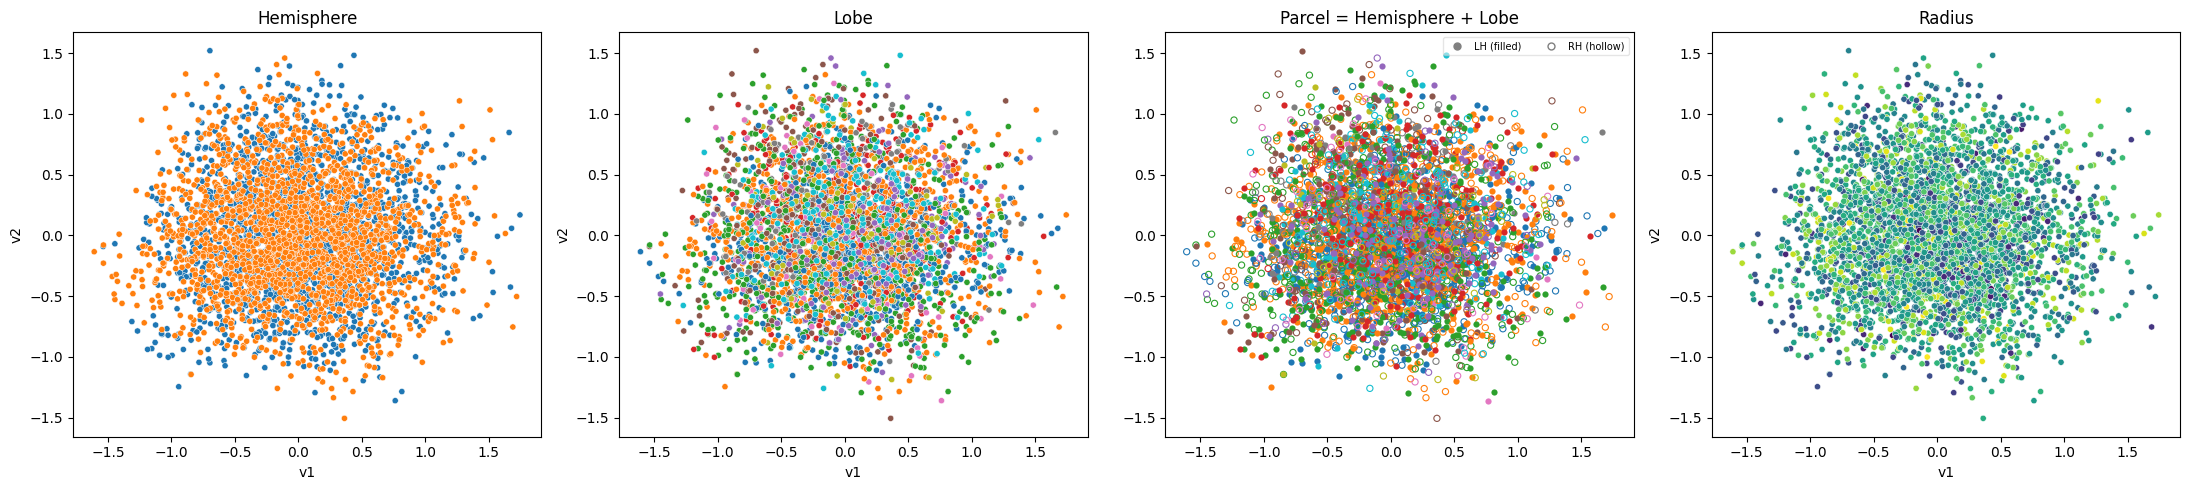

In [14]:
s_size=20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

plt.tight_layout()
plt.savefig("pca.png")
plt.show()

experiment.update_files("pca.png")

#### UMAP

In [27]:
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value is None:
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

n_neighbors = 500
reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors)
X_embed = reducer.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(4000, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,season,episode,episode_split
0,5.427022,9.437466,LH,Vis,LH_Vis,-36.200787,-35.877953,-24.405512,56.509765,1,2,a
1,3.547510,8.320223,LH,Vis,LH_Vis,-35.961187,-51.102740,-18.938356,65.294397,1,2,a
2,5.556902,10.061721,LH,Vis,LH_Vis,-26.340000,-45.000000,-14.560000,54.136764,1,2,a
3,6.888899,10.614359,LH,Vis,LH_Vis,-29.790323,-63.064516,-12.387097,70.838102,1,2,a
4,5.835252,9.487496,LH,Vis,LH_Vis,-31.905405,-43.148649,-8.581081,54.345154,1,2,a
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,5.361921,10.981063,RH,ContpCun,RH_ContpCun,8.949541,-53.655963,37.316514,65.966498,1,2,a
3996,2.401162,12.465590,RH,ContpCun,RH_ContpCun,6.946809,-51.195035,45.187943,68.637745,1,2,a
3997,4.915569,13.581963,RH,ContpCun,RH_ContpCun,5.960606,-62.960606,44.796970,77.500550,1,2,a
3998,5.006385,10.242033,RH,ContpCun,RH_ContpCun,5.890805,-37.488506,40.350575,55.391863,1,2,a


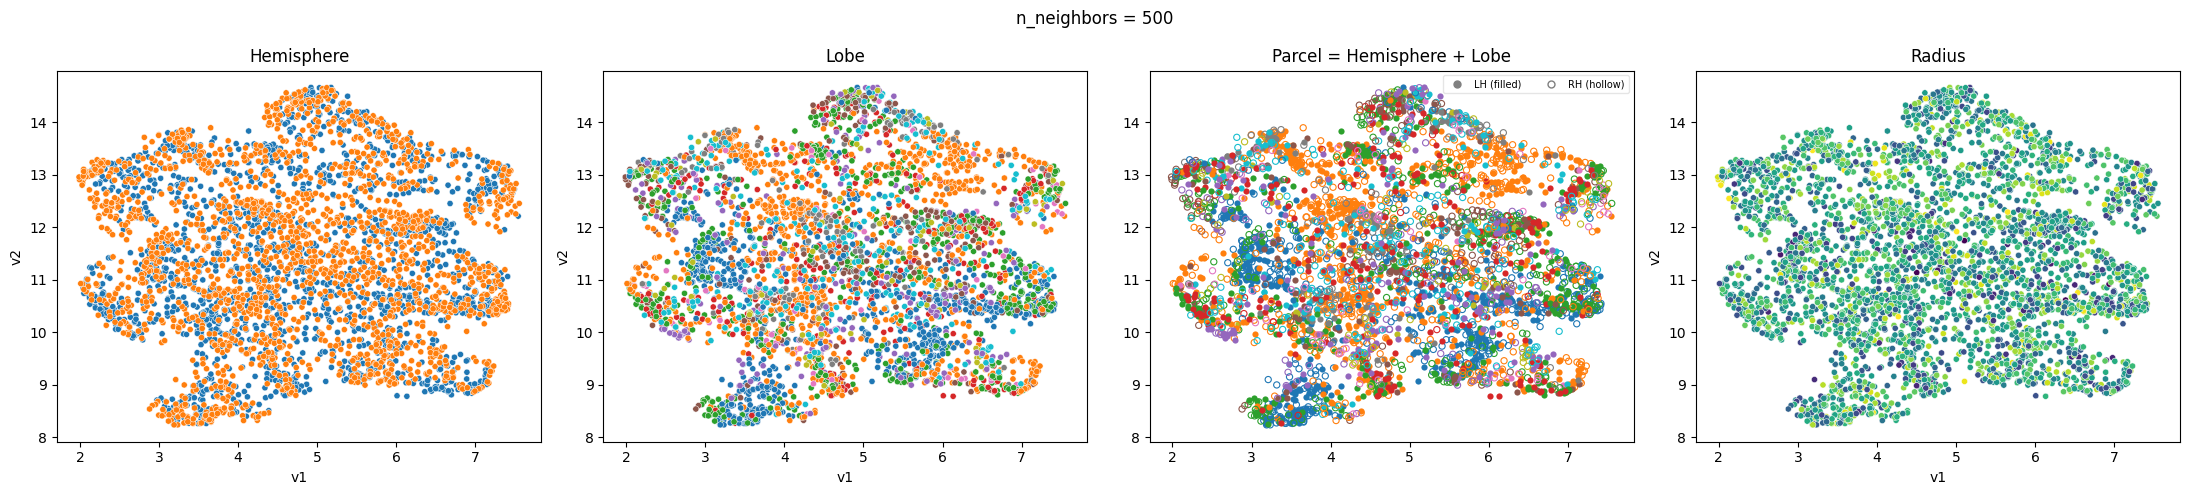

In [28]:
s_size = 20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

fig.suptitle(f"n_neighbors = {n_neighbors}")
plt.tight_layout()
plt.savefig(f'UMAP@n_neighbors={n_neighbors}.png')
plt.show()

experiment.update_files(f'UMAP@n_neighbors={n_neighbors}.png')

#### t-SNE

In [39]:
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# x_mean = X.mean(axis=-1, keepdims=True)
# x_std = X.std(axis=-1, keepdims=True)
# X_scaled = (X - x_mean) / (x_std)

x_min = X.min(axis=-1, keepdims=True)
x_max = X.max(axis=-1, keepdims=True)
X_scaled = (X - x_min) / (x_max - x_min)

# x_mean = X.mean(axis=0, keepdims=True)
# x_std = X.std(axis=-0, keepdims=True)
# X_scaled = (X - x_mean) / (x_std)

# x_min = X.min(axis=0, keepdims=True)
# x_max = X.max(axis=0, keepdims=True)
# X_scaled = (X - x_min) / (x_max - x_min)

# x_mean = X.mean()
# x_std = X.std()
# X_scaled = (X - x_mean) / (x_std)

# x_min = X.min()
# x_max = X.max()
# X_scaled = (X - x_min) / (x_max - x_min)

# X_scaled = X

perplexity = 500
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=43)
X_embed = tsne.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(4000, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,season,episode,episode_split
0,1.880700,-6.901185,LH,Vis,LH_Vis,-36.200787,-35.877953,-24.405512,56.509765,1,2,a
1,2.510300,1.852810,LH,Vis,LH_Vis,-35.961187,-51.102740,-18.938356,65.294397,1,2,a
2,5.823150,-0.342795,LH,Vis,LH_Vis,-26.340000,-45.000000,-14.560000,54.136764,1,2,a
3,4.584432,-4.381894,LH,Vis,LH_Vis,-29.790323,-63.064516,-12.387097,70.838102,1,2,a
4,2.554822,-6.746471,LH,Vis,LH_Vis,-31.905405,-43.148649,-8.581081,54.345154,1,2,a
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3.959663,-0.649217,RH,ContpCun,RH_ContpCun,8.949541,-53.655963,37.316514,65.966498,1,2,a
3996,-9.125302,2.855850,RH,ContpCun,RH_ContpCun,6.946809,-51.195035,45.187943,68.637745,1,2,a
3997,-5.973648,-4.013410,RH,ContpCun,RH_ContpCun,5.960606,-62.960606,44.796970,77.500550,1,2,a
3998,4.862855,4.622993,RH,ContpCun,RH_ContpCun,5.890805,-37.488506,40.350575,55.391863,1,2,a


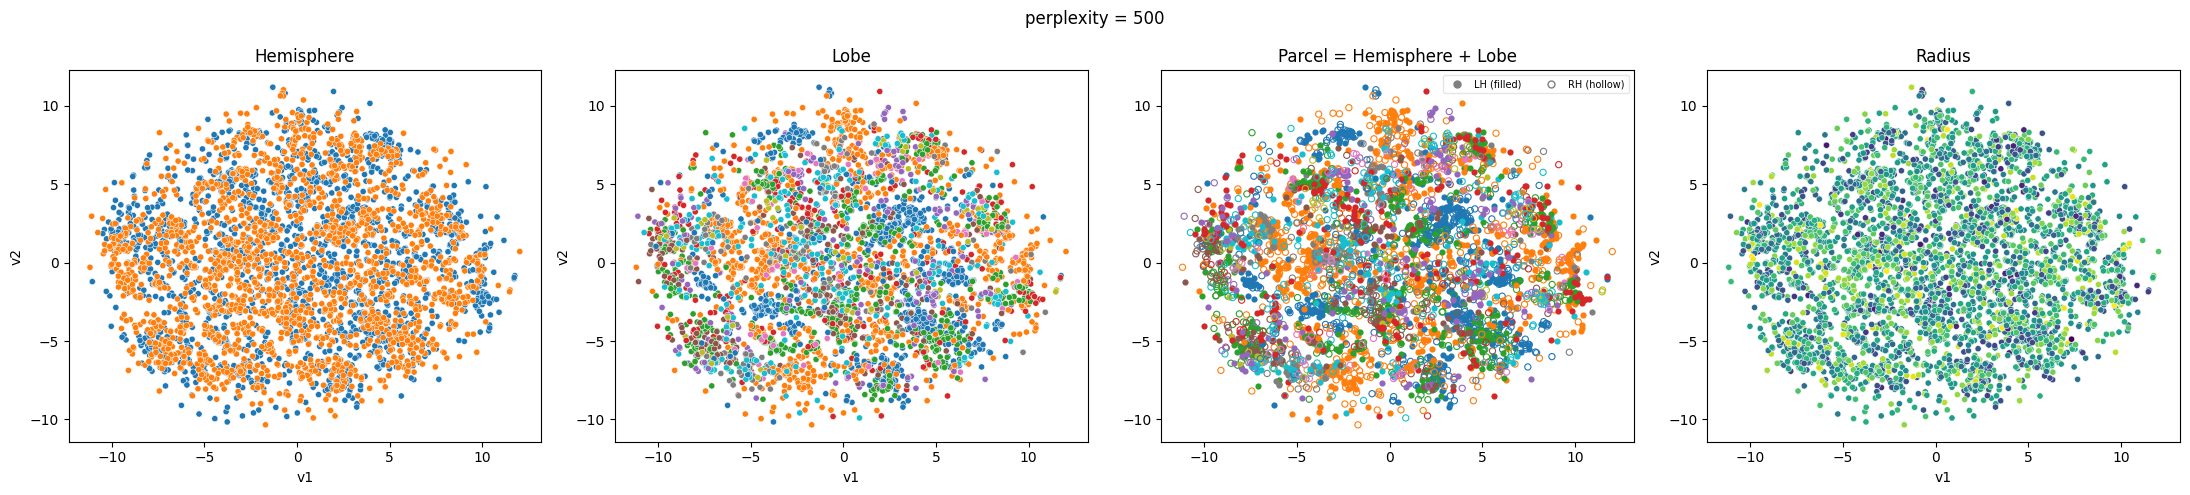

In [40]:
s_size=20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

fig.suptitle(f"perplexity = {perplexity}")
plt.tight_layout()
plt.savefig(f'tSNE@perplexity={perplexity}.png')
plt.show()

experiment.update_files(f'tSNE@perplexity={perplexity}.png')

# Save Experiment   

In [52]:
# import os

# png_files = [f for f in os.listdir() if f.endswith('.png')]
# print(png_files)
# experiment.update_files(png_files)

In [41]:
experiment.save()

Model saved to experiments/subject_episode+parcel+window_subsaomple_trials
